# I-Beam Bayesian Optimization - Interactive Teaching Demo

This notebook demonstrates key concepts in Gaussian Process regression and Bayesian Optimization using the I-beam design problem.

## Learning Objectives
1. Understand how GP models uncertainty
2. See the exploration-exploitation tradeoff
3. Compare different acquisition strategies
4. Learn about sequential vs batch optimization

In [21]:
# Import the teaching tool
# Note: This assumes ibeam_teaching_tool.py is in the same directory
import sys
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Import functions from the teaching tool
from ibeam_teaching_tool import (
    load_and_select_data, transform_4d_to_3d, train_gp,
    generate_recommendations, plot_1d_marginal, plot_2d_marginal
)

## Part 1: The Effect of Noise on GP Predictions

**Question**: How does measurement noise affect our predictions and recommendations?

We'll train two GPs:
- One assuming low noise (ideal measurements)
- One assuming high noise (realistic from retesting)

**Prediction**: Which one will have wider uncertainty bands?

In [22]:
# First, let's modify the global configuration for this demo
import ibeam_teaching_tool as itt

# Use only initial LHS data for clarity
itt.DATA_MODE = 'all'
itt.PLOT_SLICES = 1
itt.PLOT_2D_MARGINAL = 1
itt.PLOT_2D_GLOBAL = 1
itt.PLOT_1D_GLOBAL = 1

# Load data
df = load_and_select_data()
X_4d = df[['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']].values
y = df['Str/w (N/g)'].values
X_3d = transform_4d_to_3d(X_4d)

print(f"Using {len(y)} beams for comparison")

📥 Downloading data from GitHub...
✓ Loaded 45 total beams from GitHub

📊 Data Selection Mode: all
  Using all 31 valid beams
  Str/w range: [7.12, 33.60] N/g
Using 31 beams for comparison


In [23]:
# Train GP with LOW noise
print("\n" + "="*50)
print("LOW NOISE (α = 1e-3)")
print("="*50)
itt.NOISE_LEVEL = 1e-3
gp_low, X_norm, y_cent_low, y_mean_low = train_gp(X_3d, y)

# Generate recommendations
itt.ACQ_FUNCTION = 'EI'
itt.EXPLORE_EXPLOIT_DIAL = 0.3
itt.N_RECOMMENDATIONS = 3
itt.FANTASY_MODE = 'batch'
rec_low = generate_recommendations(gp_low, y_cent_low, y_mean_low, X_3d, y)


LOW NOISE (α = 1e-3)
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.205, r=0.882, dH=0.406

GENERATING 3 RECOMMENDATIONS
Acquisition: EI, Mode: batch
EI parameter ξ = 0.0061 (dial=0.30)
  Beam 1: b=6.30mm, r=3.99mm, ΔH=-0.00mm → Pred=30.20, σ=0.389, Acq=0.1051
  Beam 2: b=6.51mm, r=3.99mm, ΔH=0.15mm → Pred=29.83, σ=0.403, Acq=0.1059
  Beam 3: b=7.19mm, r=3.92mm, ΔH=0.44mm → Pred=28.82, σ=0.435, Acq=0.1053


In [24]:
# Train GP with HIGH noise
print("\n" + "="*50)
print("HIGH NOISE (α = 3e-3) - Observed from retesting")
print("="*50)
itt.NOISE_LEVEL = 3e-3
gp_high, _, y_cent_high, y_mean_high = train_gp(X_3d, y)

# Generate recommendations with same settings
rec_high = generate_recommendations(gp_high, y_cent_high, y_mean_high, X_3d, y)


HIGH NOISE (α = 3e-3) - Observed from retesting
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.190, r=0.993, dH=0.457

GENERATING 3 RECOMMENDATIONS
Acquisition: EI, Mode: batch
EI parameter ξ = 0.0061 (dial=0.30)
  Beam 1: b=7.61mm, r=3.98mm, ΔH=-0.37mm → Pred=28.24, σ=0.424, Acq=0.0942
  Beam 2: b=7.23mm, r=3.87mm, ΔH=-0.10mm → Pred=28.65, σ=0.411, Acq=0.0944
  Beam 3: b=7.19mm, r=3.92mm, ΔH=0.44mm → Pred=28.52, σ=0.418, Acq=0.0952


In [25]:
# Compare recommendations
print("\n" + "="*70)
print("COMPARISON: How Noise Affects Recommendations")
print("="*70)

print("\nLow Noise Recommendations:")
print(rec_low[['Beam', 'b', 'r', 'dH', 'Pred', 'Var']].to_string(index=False))

print("\nHigh Noise Recommendations:")
print(rec_high[['Beam', 'b', 'r', 'dH', 'Pred', 'Var']].to_string(index=False))

print("\nKey Observation:")
print(f"Average Var (Low Noise):  {rec_low['Var'].mean():.4f}")
print(f"Average Var (High Noise): {rec_high['Var'].mean():.4f}")
print("\n→ High noise leads to higher uncertainty!")


COMPARISON: How Noise Affects Recommendations

Low Noise Recommendations:
 Beam        b        r        dH      Pred      Var
    1 6.304135 3.992959 -0.004958 30.199529 0.388537
    2 6.510364 3.987204  0.146266 29.829746 0.402911
    3 7.185820 3.920379  0.442066 28.823155 0.434716

High Noise Recommendations:
 Beam        b        r        dH      Pred      Var
    1 7.608385 3.978395 -0.374108 28.242336 0.423708
    2 7.227967 3.871940 -0.102534 28.654005 0.410890
    3 7.185820 3.920379  0.442066 28.517713 0.417668

Key Observation:
Average Var (Low Noise):  0.4087
Average Var (High Noise): 0.4174

→ High noise leads to higher uncertainty!



Plotting 1D marginal effects (averaged across design space)...
  ✓ Saved: teaching_1d_marginal_all_noise3e-03.png


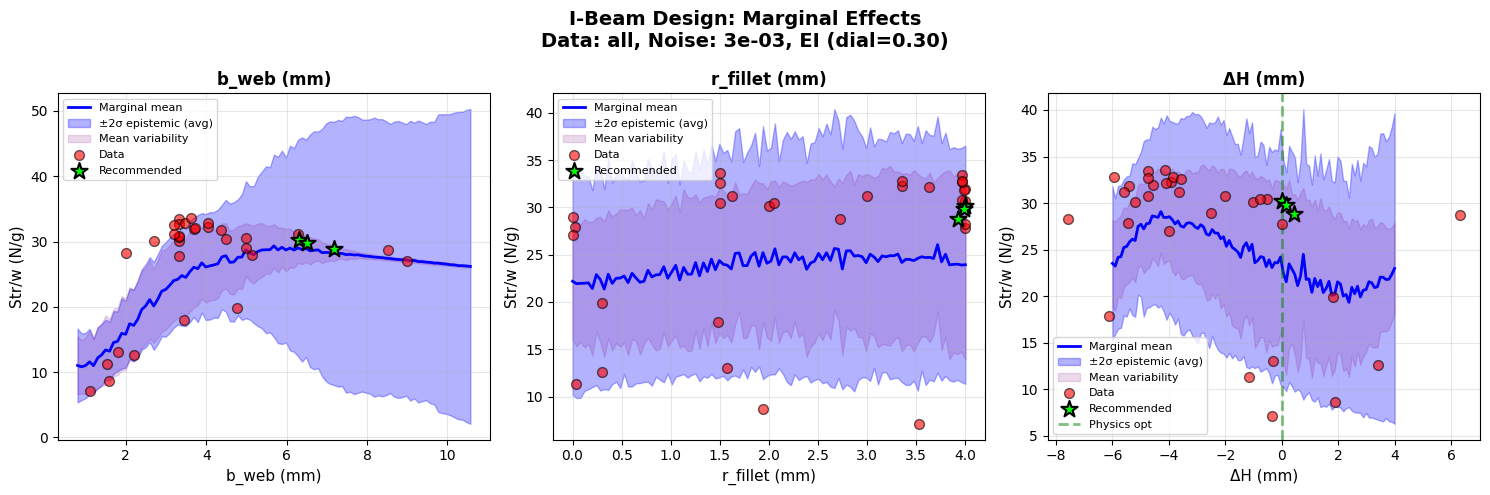

<Figure size 640x480 with 0 Axes>


Plotting 1D marginal effects (averaged across design space)...
  ✓ Saved: teaching_1d_marginal_all_noise3e-03.png


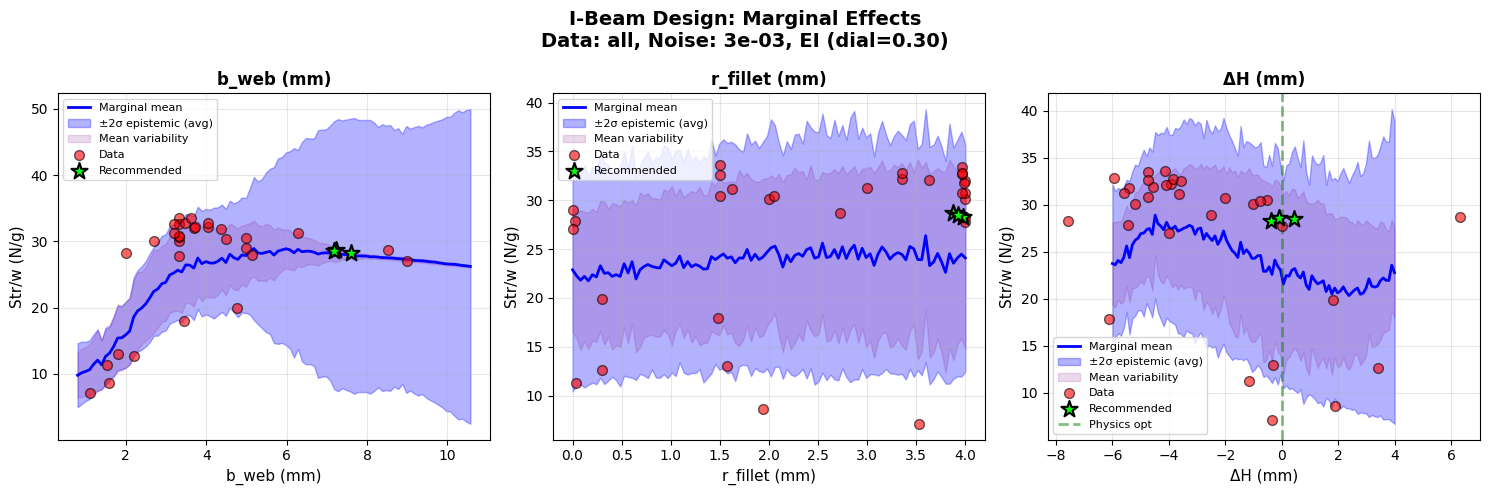

<Figure size 640x480 with 0 Axes>

In [26]:
# Visualize - you'll see the difference in uncertainty bands
itt.PLOT_1D_MARGINAL = True
plot_1d_marginal(gp_low, X_norm, y, y_mean_low, rec_low)
plt.suptitle('Low Noise (α=1e-3)', fontsize=16, weight='bold', y=1.02)
plt.show()

plot_1d_marginal(gp_high, X_norm, y, y_mean_high, rec_high)
plt.suptitle('High Noise (α=3e-3)', fontsize=16, weight='bold', y=1.02)
plt.show()

### 📊 What Did We Learn?

1. **Uncertainty Bands**: Compare the blue shaded regions (±2σ)
   - Wider with high noise
   - GP is less confident about predictions

2. **Recommendations**: May change location
   - High noise → More exploration (seek uncertain regions)
   - Low noise → More exploitation (trust the model)

3. **Real World**: Our retesting showed noise ≈ 3e-3
   - Important to use realistic noise levels!
   - Too low → Overconfident, miss optima
   - Too high → Overly cautious, slow progress

## Part 2: Exploration vs Exploitation

**Question**: Where should we test next?
- Near our best beam? (Exploitation)
- In unexplored regions? (Exploration)

Let's see what happens with different settings!

In [27]:
# Setup: Use full dataset now
itt.DATA_MODE = 'all'
df = load_and_select_data()
X_4d = df[['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']].values
y = df['Str/w (N/g)'].values
X_3d = transform_4d_to_3d(X_4d)

# Train one GP for all comparisons
itt.NOISE_LEVEL = 3e-3
gp, X_norm, y_cent, y_mean = train_gp(X_3d, y)

print(f"\nCurrent best beam: Str/w = {y.max():.2f} N/g")
print(f"Using {len(y)} beams for training")

📥 Downloading data from GitHub...
✓ Loaded 45 total beams from GitHub

📊 Data Selection Mode: all
  Using all 31 valid beams
  Str/w range: [7.12, 33.60] N/g
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.190, r=0.993, dH=0.457

Current best beam: Str/w = 33.60 N/g
Using 31 beams for training


In [28]:
# Pure Exploitation (dial = 0.0)
print("\n" + "="*50)
print("PURE EXPLOITATION (dial = 0.0)")
print("="*50)
itt.EXPLORE_EXPLOIT_DIAL = 0.0
rec_exploit = generate_recommendations(gp, y_cent, y_mean, X_3d, y)
print(rec_exploit[['Beam', 'b', 'r', 'dH', 'Pred']].to_string(index=False))


PURE EXPLOITATION (dial = 0.0)

GENERATING 3 RECOMMENDATIONS
Acquisition: EI, Mode: batch
EI parameter ξ = 0.0001 (dial=0.00)
  Beam 1: b=7.61mm, r=3.98mm, ΔH=-0.37mm → Pred=28.24, σ=0.424, Acq=0.0962
  Beam 2: b=7.23mm, r=3.87mm, ΔH=-0.10mm → Pred=28.65, σ=0.411, Acq=0.0965
  Beam 3: b=7.19mm, r=3.92mm, ΔH=0.44mm → Pred=28.52, σ=0.418, Acq=0.0973
 Beam        b        r        dH      Pred
    1 7.608385 3.978395 -0.374108 28.242336
    2 7.227967 3.871940 -0.102534 28.654005
    3 7.185820 3.920379  0.442066 28.517713


In [29]:
# Balanced (dial = 0.5)
print("\n" + "="*50)
print("BALANCED (dial = 0.5)")
print("="*50)
itt.EXPLORE_EXPLOIT_DIAL = 0.5
rec_balanced = generate_recommendations(gp, y_cent, y_mean, X_3d, y)
print(rec_balanced[['Beam', 'b', 'r', 'dH', 'Pred']].to_string(index=False))


BALANCED (dial = 0.5)

GENERATING 3 RECOMMENDATIONS
Acquisition: EI, Mode: batch
EI parameter ξ = 0.0100 (dial=0.50)
  Beam 1: b=7.61mm, r=3.98mm, ΔH=-0.37mm → Pred=28.24, σ=0.424, Acq=0.0928
  Beam 2: b=7.23mm, r=3.87mm, ΔH=-0.10mm → Pred=28.65, σ=0.411, Acq=0.0930
  Beam 3: b=7.19mm, r=3.92mm, ΔH=0.44mm → Pred=28.52, σ=0.418, Acq=0.0939
 Beam        b        r        dH      Pred
    1 7.608385 3.978395 -0.374108 28.242336
    2 7.227967 3.871940 -0.102534 28.654005
    3 7.185820 3.920379  0.442066 28.517713


In [30]:
# Pure Exploration (dial = 1.0)
print("\n" + "="*50)
print("PURE EXPLORATION (dial = 1.0)")
print("="*50)
itt.EXPLORE_EXPLOIT_DIAL = 1.0
rec_explore = generate_recommendations(gp, y_cent, y_mean, X_3d, y)
print(rec_explore[['Beam', 'b', 'r', 'dH', 'Pred']].to_string(index=False))


PURE EXPLORATION (dial = 1.0)

GENERATING 3 RECOMMENDATIONS
Acquisition: EI, Mode: batch
EI parameter ξ = 0.0200 (dial=1.00)
  Beam 1: b=7.61mm, r=3.98mm, ΔH=-0.37mm → Pred=28.24, σ=0.424, Acq=0.0896
  Beam 2: b=7.23mm, r=3.87mm, ΔH=-0.10mm → Pred=28.65, σ=0.411, Acq=0.0897
  Beam 3: b=7.19mm, r=3.92mm, ΔH=0.44mm → Pred=28.52, σ=0.418, Acq=0.0906
 Beam        b        r        dH      Pred
    1 7.608385 3.978395 -0.374108 28.242336
    2 7.227967 3.871940 -0.102534 28.654005
    3 7.185820 3.920379  0.442066 28.517713


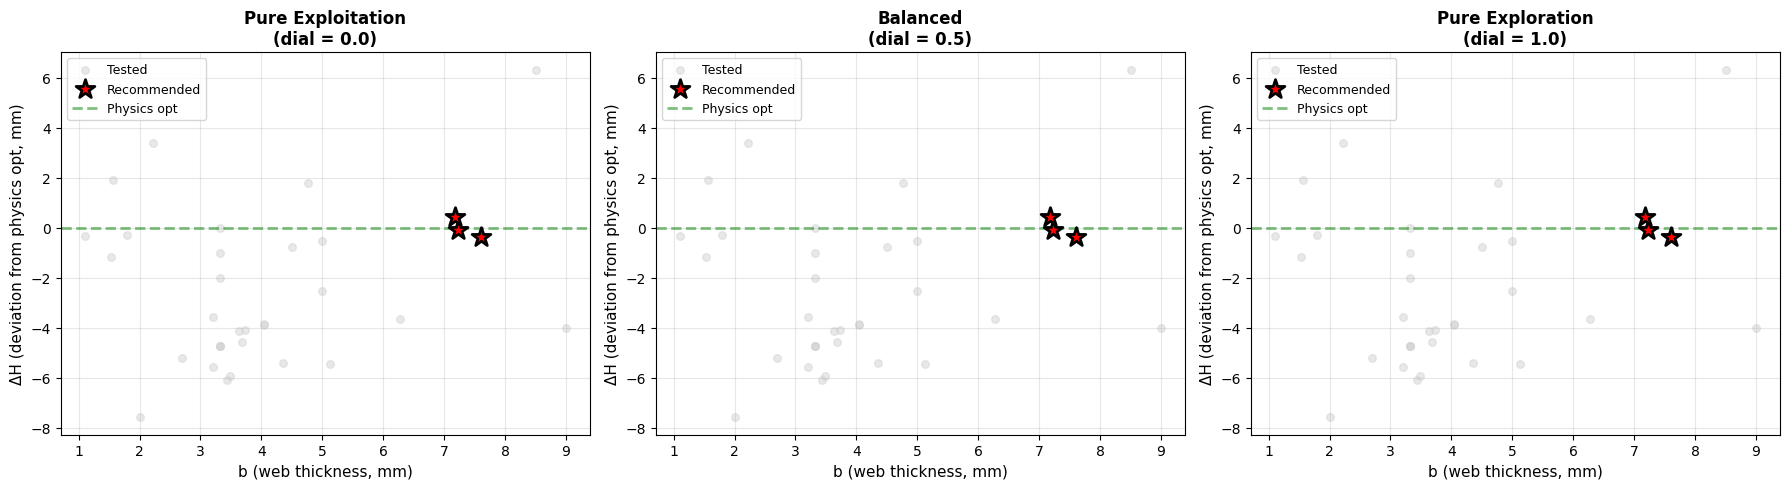

In [31]:
# Compare all three on 2D plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, rec, dial, title in zip(
    axes,
    [rec_exploit, rec_balanced, rec_explore],
    [0.0, 0.5, 1.0],
    ['Pure Exploitation', 'Balanced', 'Pure Exploration']
):
    # Plot design space (b vs ΔH)
    from ibeam_teaching_tool import denormalize
    X_den = denormalize(X_norm)

    ax.scatter(X_den[:, 0], X_den[:, 2], c='lightgray', s=30, alpha=0.5, label='Tested')
    ax.scatter(rec['b'], rec['dH'], c='red', s=200, marker='*',
              edgecolors='black', linewidths=2, label='Recommended', zorder=10)

    ax.set_xlabel('b (web thickness, mm)', fontsize=11)
    ax.set_ylabel('ΔH (deviation from physics opt, mm)', fontsize=11)
    ax.set_title(f'{title}\n(dial = {dial})', fontsize=12, weight='bold')
    ax.axhline(0, color='green', ls='--', alpha=0.5, lw=2, label='Physics opt')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 What Did We Learn?

1. **Exploitation (dial=0.0)**:
   - Recommends near current best
   - Safe, but may miss global optimum
   - Good when: Refining a known good design

2. **Balanced (dial=0.5)**:
   - Mix of local and global search
   - Most versatile setting
   - Good when: General optimization

3. **Exploration (dial=1.0)**:
   - Recommends in uncertain regions
   - May seem risky, but prevents local optima
   - Good when: Early stages, sparse data

**Real Strategy**: Start with high exploration (0.7), reduce to exploitation (0.2) as you converge

## Part 3: EI vs UCB

Two popular acquisition functions:
- **Expected Improvement (EI)**: Focus on improving over current best
- **Upper Confidence Bound (UCB)**: Optimistic strategy, explores uncertainty

Which is better? Let's find out!

In [32]:
# Use LHS data for clearer comparison
itt.DATA_MODE = 'lhs_only'
df = load_and_select_data()
X_4d = df[['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']].values
y = df['Str/w (N/g)'].values
X_3d = transform_4d_to_3d(X_4d)

itt.NOISE_LEVEL = 1e-3
gp, X_norm, y_cent, y_mean = train_gp(X_3d, y)

# Fair comparison: balanced exploration
itt.EXPLORE_EXPLOIT_DIAL = 0.5
itt.N_RECOMMENDATIONS = 5

📥 Downloading data from GitHub...
✓ Loaded 45 total beams from GitHub

📊 Data Selection Mode: lhs_only
  Using first 15 beams (LHS initial samples)
  Str/w range: [7.12, 33.45] N/g
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.174, r=0.769, dH=2.095


In [33]:
# Expected Improvement
print("\n" + "="*50)
print("EXPECTED IMPROVEMENT (EI)")
print("="*50)
itt.ACQ_FUNCTION = 'EI'
rec_ei = generate_recommendations(gp, y_cent, y_mean, X_3d, y)
print(rec_ei[['Beam', 'b', 'r', 'dH', 'Pred', 'AcqVal']].to_string(index=False))


EXPECTED IMPROVEMENT (EI)

GENERATING 5 RECOMMENDATIONS
Acquisition: EI, Mode: batch
EI parameter ξ = 0.0100 (dial=0.50)
  Beam 1: b=7.70mm, r=0.01mm, ΔH=-4.34mm → Pred=27.80, σ=0.390, Acq=0.0771
  Beam 2: b=7.43mm, r=0.06mm, ΔH=-3.40mm → Pred=28.39, σ=0.367, Acq=0.0754
  Beam 3: b=7.47mm, r=0.13mm, ΔH=-3.81mm → Pred=28.42, σ=0.366, Acq=0.0753
  Beam 4: b=7.58mm, r=0.15mm, ΔH=-4.14mm → Pred=28.21, σ=0.373, Acq=0.0759
  Beam 5: b=7.66mm, r=0.08mm, ΔH=-4.04mm → Pred=27.95, σ=0.383, Acq=0.0764
 Beam        b        r        dH      Pred   AcqVal
    1 7.697206 0.010691 -4.335984 27.795238 0.077100
    2 7.426279 0.058753 -3.399773 28.388401 0.075359
    3 7.465252 0.132072 -3.814791 28.416777 0.075314
    4 7.575777 0.152303 -4.137649 28.214727 0.075852
    5 7.661099 0.079412 -4.043481 27.945893 0.076361


In [34]:
# Upper Confidence Bound
print("\n" + "="*50)
print("UPPER CONFIDENCE BOUND (UCB)")
print("="*50)
itt.ACQ_FUNCTION = 'UCB'
rec_ucb = generate_recommendations(gp, y_cent, y_mean, X_3d, y)
print(rec_ucb[['Beam', 'b', 'r', 'dH', 'Pred', 'AcqVal']].to_string(index=False))


UPPER CONFIDENCE BOUND (UCB)

GENERATING 5 RECOMMENDATIONS
Acquisition: UCB, Mode: batch
UCB parameter κ = 1.1000 (dial=0.50)
  Beam 1: b=7.70mm, r=0.01mm, ΔH=-4.34mm → Pred=27.80, σ=0.390, Acq=0.7061
  Beam 2: b=7.43mm, r=0.06mm, ΔH=-3.40mm → Pred=28.39, σ=0.367, Acq=0.7013
  Beam 3: b=7.47mm, r=0.13mm, ΔH=-3.81mm → Pred=28.42, σ=0.366, Acq=0.7012
  Beam 4: b=7.58mm, r=0.15mm, ΔH=-4.14mm → Pred=28.21, σ=0.373, Acq=0.7027
  Beam 5: b=7.66mm, r=0.08mm, ΔH=-4.04mm → Pred=27.95, σ=0.383, Acq=0.7040
 Beam        b        r        dH      Pred   AcqVal
    1 7.697206 0.010691 -4.335984 27.795238 0.706089
    2 7.426279 0.058753 -3.399773 28.388401 0.701284
    3 7.465252 0.132072 -3.814791 28.416777 0.701166
    4 7.575777 0.152303 -4.137649 28.214727 0.702670
    5 7.661099 0.079412 -4.043481 27.945893 0.703972


In [35]:
# Compare predictions and uncertainties
comparison = pd.DataFrame({
    'EI_Pred': rec_ei['Pred'].values,
    'UCB_Pred': rec_ucb['Pred'].values,
    'EI_Var': rec_ei['Var'].values,
    'UCB_Var': rec_ucb['Var'].values,
})

print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(comparison.to_string())

print("\nKey Differences:")
print(f"EI avg uncertainty:  {rec_ei['Var'].mean():.4f}")
print(f"UCB avg uncertainty: {rec_ucb['Var'].mean():.4f}")
print("\n→ UCB typically explores higher uncertainty regions!")


COMPARISON
     EI_Pred   UCB_Pred    EI_Var   UCB_Var
0  27.795238  27.795238  0.390154  0.390154
1  28.388401  28.388401  0.366589  0.366589
2  28.416777  28.416777  0.365574  0.365574
3  28.214727  28.214727  0.373428  0.373428
4  27.945893  27.945893  0.383315  0.383315

Key Differences:
EI avg uncertainty:  0.3758
UCB avg uncertainty: 0.3758

→ UCB typically explores higher uncertainty regions!


### 📊 When to Use Each?

**Expected Improvement (EI)**:
- ✅ Limited budget for testing
- ✅ Want guaranteed improvement
- ✅ Know you're near the optimum
- ❌ May converge prematurely

**Upper Confidence Bound (UCB)**:
- ✅ Exploring a new design space
- ✅ Want to understand the entire space
- ✅ Can afford more tests
- ❌ May be inefficient near optimum

**Recommendation**: Start with UCB, switch to EI for final refinement

## Part 4: Sequential vs Batch Optimization

**Sequential**: Test beam 1, update GP, recommend beam 2, update GP, ...
**Batch**: Recommend all beams at once (parallel testing)

Which gives more diverse recommendations?

In [36]:
# Use full dataset
itt.DATA_MODE = 'all'
df = load_and_select_data()
X_4d = df[['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']].values
y = df['Str/w (N/g)'].values
X_3d = transform_4d_to_3d(X_4d)

itt.NOISE_LEVEL = 3e-3
gp, X_norm, y_cent, y_mean = train_gp(X_3d, y)

itt.ACQ_FUNCTION = 'EI'
itt.EXPLORE_EXPLOIT_DIAL = 0.3
itt.N_RECOMMENDATIONS = 5

📥 Downloading data from GitHub...
✓ Loaded 45 total beams from GitHub

📊 Data Selection Mode: all
  Using all 31 valid beams
  Str/w range: [7.12, 33.60] N/g
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.190, r=0.993, dH=0.457


In [37]:
# Batch mode
print("\n" + "="*50)
print("BATCH MODE (all from same GP)")
print("="*50)
itt.FANTASY_MODE = 'batch'
rec_batch = generate_recommendations(gp, y_cent, y_mean, X_3d, y)
print(rec_batch[['Beam', 'b', 'r', 'dH', 'Pred']].to_string(index=False))


BATCH MODE (all from same GP)

GENERATING 5 RECOMMENDATIONS
Acquisition: EI, Mode: batch
EI parameter ξ = 0.0061 (dial=0.30)
  Beam 1: b=7.61mm, r=3.98mm, ΔH=-0.37mm → Pred=28.24, σ=0.424, Acq=0.0942
  Beam 2: b=7.23mm, r=3.87mm, ΔH=-0.10mm → Pred=28.65, σ=0.411, Acq=0.0944
  Beam 3: b=7.19mm, r=3.92mm, ΔH=0.44mm → Pred=28.52, σ=0.418, Acq=0.0952
  Beam 4: b=7.30mm, r=3.90mm, ΔH=-0.05mm → Pred=28.55, σ=0.415, Acq=0.0947
  Beam 5: b=6.97mm, r=3.95mm, ΔH=0.47mm → Pred=28.70, σ=0.411, Acq=0.0952
 Beam        b        r        dH      Pred
    1 7.608385 3.978395 -0.374108 28.242336
    2 7.227967 3.871940 -0.102534 28.654005
    3 7.185820 3.920379  0.442066 28.517713
    4 7.296157 3.896516 -0.050689 28.554956
    5 6.970667 3.951313  0.473823 28.704553


In [38]:
# Sequential mode
print("\n" + "="*50)
print("SEQUENTIAL MODE (update GP after each)")
print("="*50)
itt.FANTASY_MODE = 'sequential'
rec_seq = generate_recommendations(gp, y_cent, y_mean, X_3d, y)
print(rec_seq[['Beam', 'b', 'r', 'dH', 'Pred']].to_string(index=False))


SEQUENTIAL MODE (update GP after each)

GENERATING 5 RECOMMENDATIONS
Acquisition: EI, Mode: sequential
EI parameter ξ = 0.0061 (dial=0.30)
  Beam 1: b=7.61mm, r=3.98mm, ΔH=-0.37mm → Pred=28.24, σ=0.424, Acq=0.0942
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.186, r=0.988, dH=0.453
    → GP updated with fantasy observation
  Beam 2: b=10.63mm, r=0.46mm, ΔH=3.65mm → Pred=26.36, σ=0.459, Acq=0.0850
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.180, r=0.961, dH=0.438
    → GP updated with fantasy observation
  Beam 3: b=5.64mm, r=3.89mm, ΔH=-1.88mm → Pred=31.98, σ=0.258, Acq=0.0776
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.187, r=1.007, dH=0.439
    → GP updated with fantasy observation
  Beam 4: b=10.45mm, r=2.67mm, ΔH=-1.82mm → Pred=26.20, σ=0.393, Acq=0.0612
  Using FREE ARD length scales (will learn per dimension)
  Learned length scales: b=0.183, r=0.999, dH

In [39]:
# Measure diversity
def diversity_score(rec):
    """Compute average pairwise distance between recommendations"""
    points = rec[['b', 'r', 'dH']].values
    n = len(points)
    total_dist = 0
    count = 0
    for i in range(n):
        for j in range(i+1, n):
            total_dist += np.linalg.norm(points[i] - points[j])
            count += 1
    return total_dist / count if count > 0 else 0

div_batch = diversity_score(rec_batch)
div_seq = diversity_score(rec_seq)

print("\n" + "="*50)
print("DIVERSITY COMPARISON")
print("="*50)
print(f"Batch diversity:      {div_batch:.3f}")
print(f"Sequential diversity: {div_seq:.3f}")
print(f"\n→ Sequential is {(div_seq/div_batch - 1)*100:.1f}% more diverse!")


DIVERSITY COMPARISON
Batch diversity:      0.554
Sequential diversity: 5.597

→ Sequential is 910.7% more diverse!


### 📊 Key Takeaways

**Batch Mode**:
- ✅ Fast (one GP training)
- ✅ Good for parallel testing
- ❌ May recommend similar designs
- ❌ Less information-efficient

**Sequential Mode**:
- ✅ More diverse recommendations
- ✅ Adapts to "fantasy" observations
- ✅ Better coverage of design space
- ❌ Slower (multiple GP trainings)
- ❌ Assumes iterative testing

**Real World**: Use sequential if you test beams one at a time. Use batch if you can print and test multiple beams simultaneously.

## Summary: What We Learned

### 1. Noise Matters
- Higher noise → More uncertainty → More exploration
- Use realistic noise (3e-3 from our retesting)

### 2. Exploration-Exploitation Tradeoff
- Start exploring (dial ≈ 0.7)
- Transition to exploitation (dial ≈ 0.2)
- Balance depends on stage of optimization

### 3. Acquisition Functions
- EI: Conservative, improvement-focused
- UCB: Optimistic, exploration-focused
- Both are valid strategies

### 4. Sequential vs Batch
- Sequential: Better diversity, more adaptive
- Batch: Faster, good for parallel testing

### Next Steps
1. Run the full teaching tool with your own configurations
2. Generate recommendations for your next round of testing
3. Compare human vs algorithm performance
4. Learn from both successes and failures!

---

**Good luck with your I-beam competition!** 🎯